In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv('placement.csv')

In [3]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [4]:
df.shape

(100, 4)

In [5]:
df.ndim

2

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [7]:
df=df.iloc[:,1:] #prepossing

In [8]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [9]:
import matplotlib.pyplot as plt

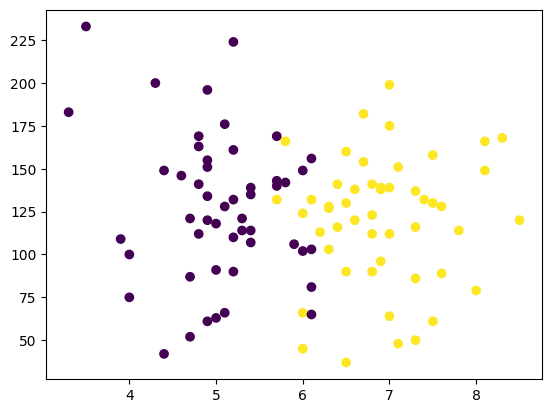

In [10]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [11]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [12]:
y.shape

(100,)

In [13]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.1)

In [14]:
x_train

,cgpa,iq
17,3.3,183.0
77,7.3,50.0
28,5.2,90.0
64,7.0,64.0
86,5.1,128.0
...,...,...
82,6.5,37.0
50,3.5,233.0
66,6.9,96.0
4,5.8,142.0


In [15]:
x_test

,cgpa,iq
25,5.0,91.0
73,4.9,61.0
56,6.1,65.0
68,4.0,75.0
37,8.1,149.0
7,5.0,63.0
54,6.4,141.0
33,6.0,149.0
39,4.6,146.0
36,5.7,140.0


In [16]:
y_test

25    0
73    0
56    0
68    0
37    1
7     0
54    1
33    0
39    0
36    0
Name: placement, dtype: int64

In [17]:
from sklearn.preprocessing import StandardScaler

In [18]:
scaler= StandardScaler()

In [19]:
x_train = scaler.fit_transform(x_train)

In [20]:
x_train

array([[-2.41544776,  1.45809819],
       [ 1.11504836, -1.90350338],
       [-0.73846211, -0.89249539],
       [ 0.85026115, -1.54965058],
       [-0.82672451,  0.0679622 ],
       [ 1.11504836,  0.295439  ],
       [-0.91498691, -0.18478979],
       [ 1.29157317,  0.8262182 ],
       [-0.29715009,  0.4470902 ],
       [ 0.67373634, -0.33644099],
       [ 0.05589952,  0.7756678 ],
       [ 1.55636037, -0.28589059],
       [ 0.49721154,  0.3207142 ],
       [ 0.67373634,  0.3965398 ],
       [ 0.32068673, -0.23534019],
       [-0.73846211, -0.38699139],
       [-1.09151172,  1.10424539],
       [-0.03236288, -0.58919299],
       [ 0.67373634, -0.89249539],
       [-0.03236288, -2.02987938],
       [-0.03236288, -1.49910018],
       [-1.00324932,  1.78667579],
       [ 0.05589952, -1.11997218],
       [-1.09151172,  0.9525942 ],
       [ 1.37983557, -0.91777059],
       [ 0.23242433,  0.042687  ],
       [ 0.85026115,  1.25589659],
       [ 0.23242433,  0.0679622 ],
       [ 0.58547394,

In [21]:
x_test=scaler.transform(x_test)

In [22]:
x_test

array([[-0.91498691, -0.86722019],
       [-1.00324932, -1.62547618],
       [ 0.05589952, -1.52437538],
       [-1.79761094, -1.27162338],
       [ 1.82114758,  0.5987414 ],
       [-0.91498691, -1.57492578],
       [ 0.32068673,  0.3965398 ],
       [-0.03236288,  0.5987414 ],
       [-1.26803652,  0.5229158 ],
       [-0.29715009,  0.3712646 ]])

In [23]:
from sklearn.linear_model import LogisticRegression

In [24]:
clf = LogisticRegression()

In [25]:
#model trainnig
clf.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [30]:
from mlxtend.plotting import plot_decision_regions